In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import yaml
from pathlib import Path


pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
def load_config(config_path):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config

In [3]:
base_path = Path.cwd().parent
config_path = base_path / "config" / "config.yaml"
cfg = load_config(config_path)
data_path = cfg["paths"]["raw_path"]

In [4]:
df = pd.read_csv(base_path / data_path)

In [31]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.647,-73.972,Private room,149,1,9,2018-10-19,0.210,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.754,-73.984,Entire home/apt,225,1,45,2019-05-21,0.380,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.809,-73.942,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.685,-73.960,Entire home/apt,89,1,270,2019-07-05,4.640,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.799,-73.944,Entire home/apt,80,10,9,2018-11-19,0.100,1,0


In [32]:
drop_cols = ["id", "name", "host_id", "host_name"]
df = df.drop(drop_cols, axis=1)

In [33]:
df.shape

(48597, 12)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48597 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48597 non-null  object 
 1   neighbourhood                   48597 non-null  object 
 2   latitude                        48597 non-null  float64
 3   longitude                       48597 non-null  float64
 4   room_type                       48597 non-null  object 
 5   price                           48597 non-null  int64  
 6   minimum_nights                  48597 non-null  int64  
 7   number_of_reviews               48597 non-null  int64  
 8   last_review                     38706 non-null  object 
 9   reviews_per_month               38706 non-null  float64
 10  calculated_host_listings_count  48597 non-null  int64  
 11  availability_365                48597 non-null  int64  
dtypes: float64(3), int64(5), object(4)
me

In [35]:
df.isnull().sum()

neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       9891
reviews_per_month                 9891
calculated_host_listings_count       0
availability_365                     0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,48597.000,40.729,0.055,40.500,40.690,40.723,40.763,40.913
longitude,48597.000,-73.952,0.046,-74.244,-73.983,-73.956,-73.936,-73.713
price,48597.000,140.237,112.906,0.000,69.000,105.000,175.000,999.000
minimum_nights,48597.000,6.975,20.275,1.000,1.000,3.000,5.000,1250.000
number_of_reviews,48597.000,23.375,44.651,0.000,1.000,5.000,24.000,629.000
reviews_per_month,38706.000,1.375,1.682,0.010,0.190,0.720,2.020,58.500
calculated_host_listings_count,48597.000,7.168,33.042,1.000,1.000,1.000,2.000,327.000
availability_365,48597.000,112.368,131.379,0.000,0.000,44.000,225.000,365.000


In [38]:
df = df[df["price"] < 1000]

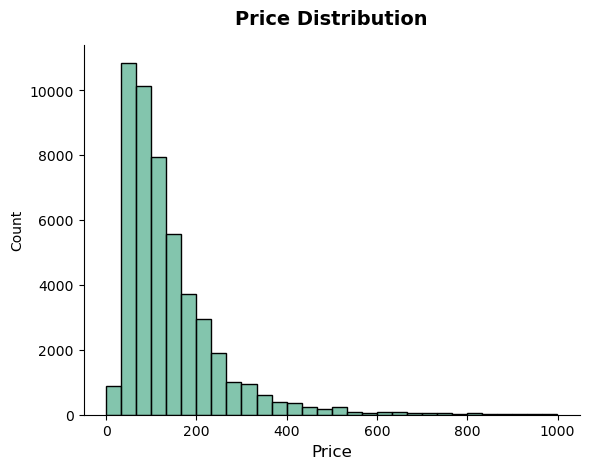

In [69]:
ax = sns.histplot(data=df, x="price", bins=30, color="#59B292")
sns.despine(ax=ax)
plt.title("Price Distribution", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Price", fontsize=12)
plt.show()

In [40]:
df["room_type"].value_counts()

room_type
Entire home/apt    25166
Private room       22275
Shared room         1156
Name: count, dtype: int64

In [41]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21448
Brooklyn         20037
Queens            5653
Bronx             1089
Staten Island      370
Name: count, dtype: int64

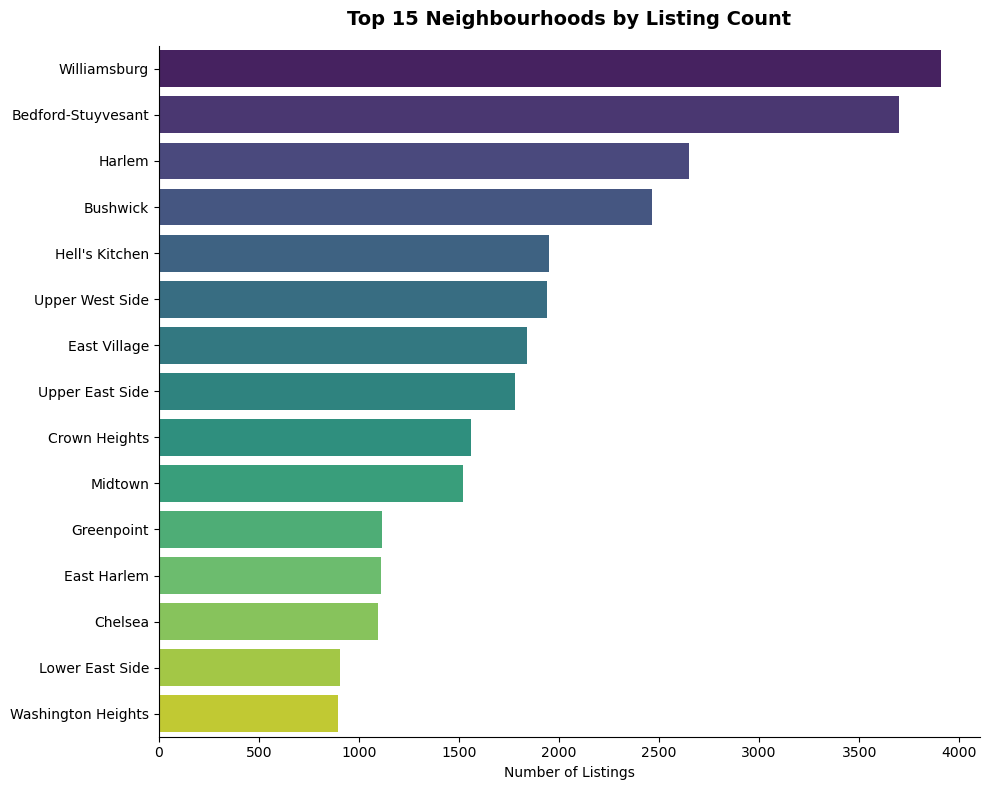

In [ ]:
top_n = df["neighbourhood"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(x=top_n.values, y=top_n.index, hue=top_n.index, palette="viridis", legend=False, ax=ax)
sns.despine(ax=ax)
ax.set_title("Top 15 Neighbourhoods by Listing Count",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Listings")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

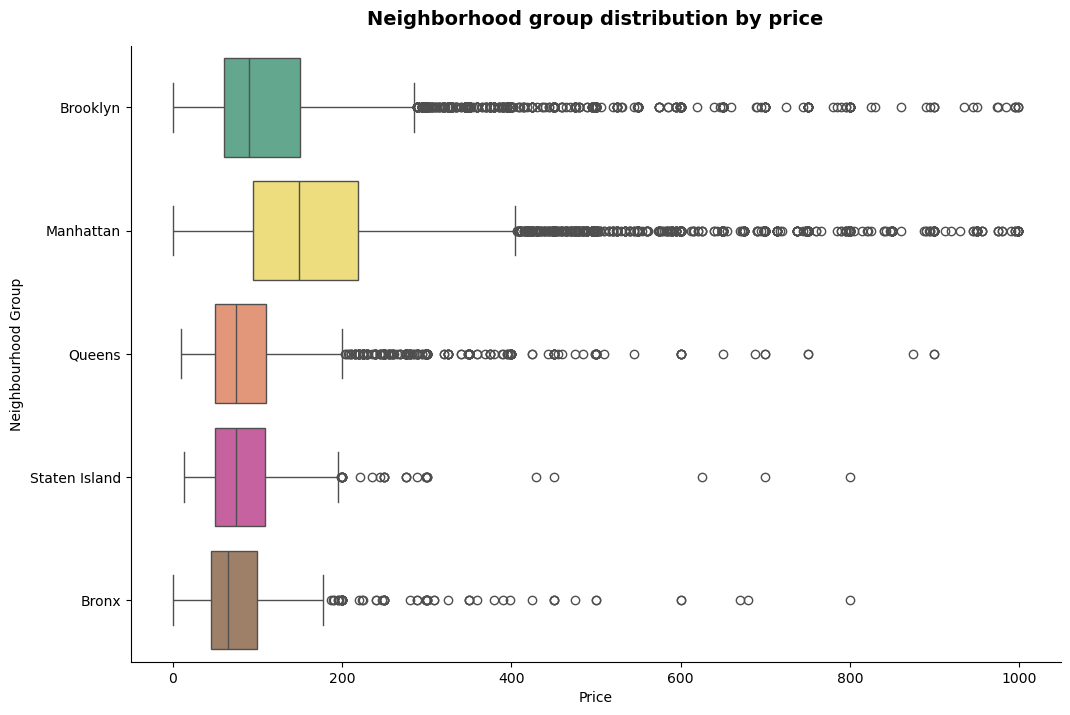

In [86]:
palettes = ["#59B292", "#FFEA6C", "#F48F68", "#D552A3", "#A77F60"]

fig, ax = plt.subplots(figsize=(12,8))
sns.boxplot(data=df, x="price", y="neighbourhood_group", hue="neighbourhood_group", palette=palettes, legend=False, ax=ax)
sns.despine(ax=ax)
ax.set_title("Neighborhood group distribution by price", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Price")
ax.set_ylabel("Neighbourhood Group")
plt.show()

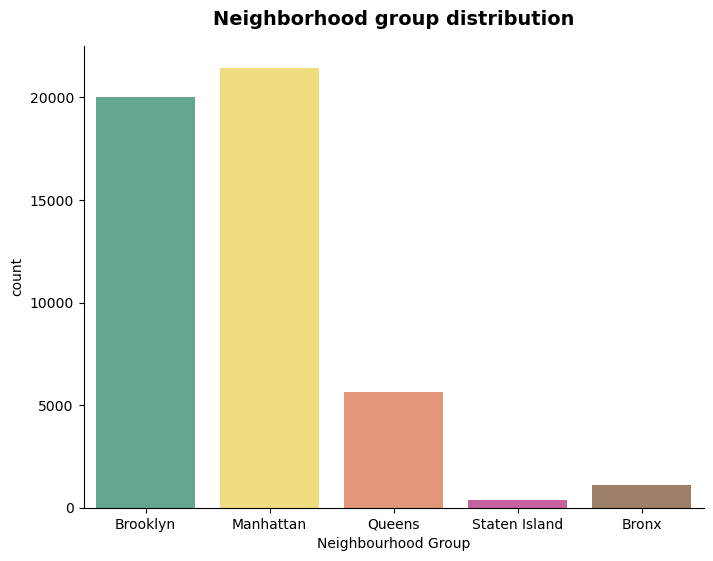

In [88]:
fig, ax = plt.subplots(figsize=(8,6))

sns.countplot(data=df, x="neighbourhood_group", hue="neighbourhood_group", palette=palettes, legend=False, ax=ax)
sns.despine(ax=ax)
ax.set_title("Neighborhood group distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Neighbourhood Group")
plt.show()

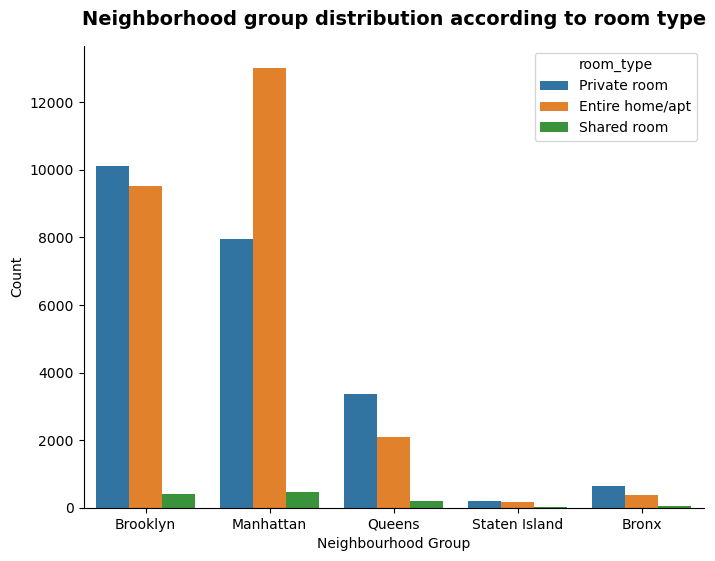

In [103]:
fig, ax = plt.subplots(figsize=(8,6))

sns.countplot(data=df, x="neighbourhood_group", hue="room_type", ax=ax)
sns.despine(ax=ax)
ax.set_title("Neighborhood group distribution according to room type", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Neighbourhood Group")
ax.set_ylabel("Count")
plt.show()

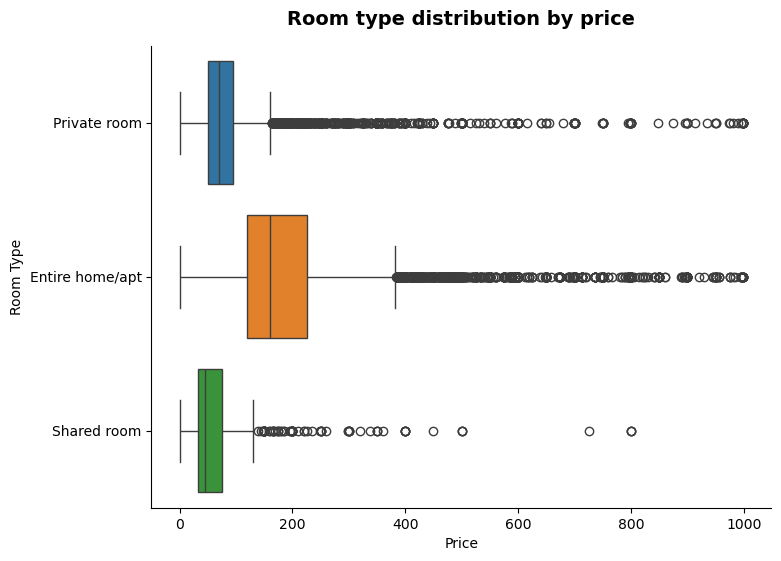

In [101]:
fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=df, x="price", y="room_type", hue="room_type", ax=ax)
sns.despine(ax=ax)
ax.set_title("Room type distribution by price", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Price")
ax.set_ylabel("Room Type")
plt.show()

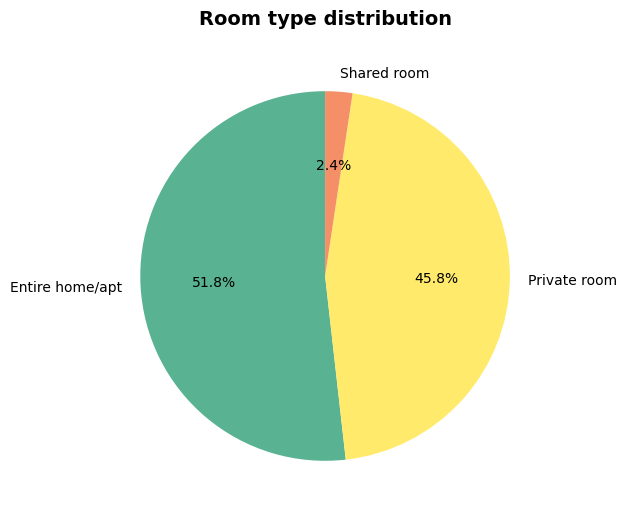

In [91]:
room_type_counts = df["room_type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    room_type_counts,
    labels=room_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=palettes
)

plt.title("Room type distribution", fontsize=14, fontweight="bold", pad=15)
plt.show()

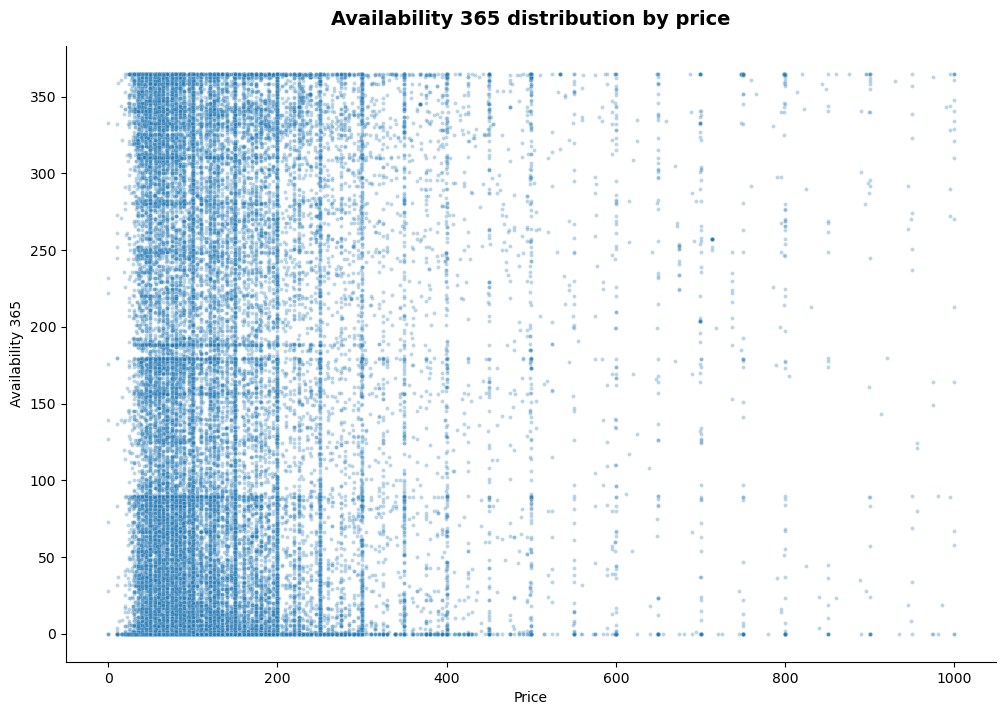

In [104]:
fig, ax = plt.subplots(figsize=(12,8))
sns.scatterplot(data=df, x="price", y="availability_365", alpha=0.3, s=8, ax=ax)
sns.despine(ax=ax)
ax.set_title("Availability 365 distribution by price", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Price")
ax.set_ylabel("Availability 365")
plt.show()

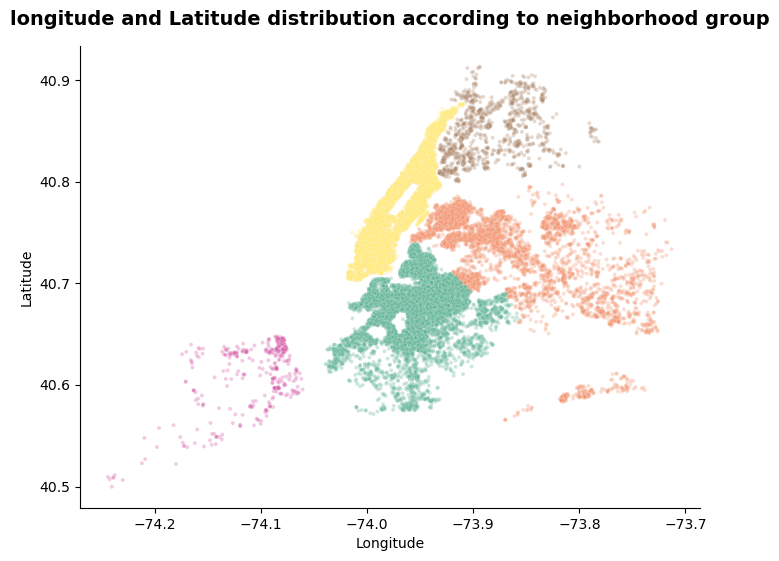

In [106]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x="longitude", y="latitude", hue="neighbourhood_group", palette=palettes, alpha=0.3, s=8, legend=False, ax=ax)
sns.despine(ax=ax)
ax.set_title("longitude and Latitude distribution according to neighborhood group", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

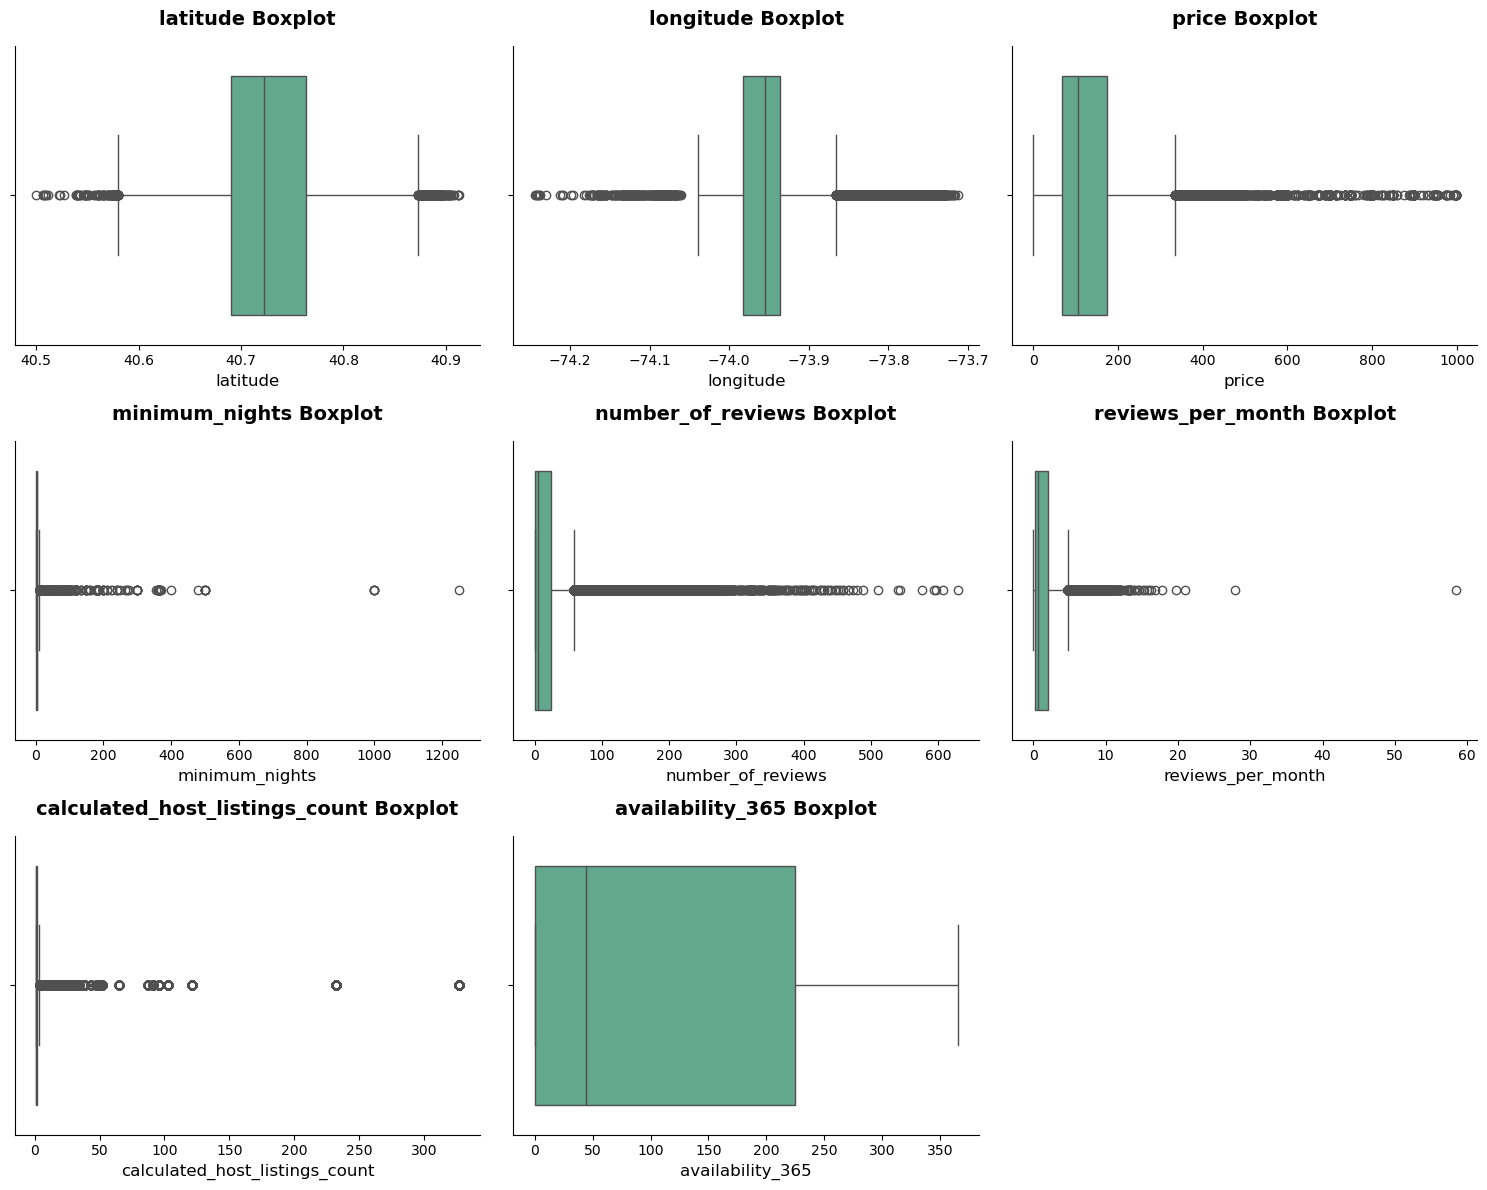

In [47]:
num_cols = df.select_dtypes(include="number").columns

n_cols = 3
n_rows = math.ceil(len(num_cols)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color="#59B292")
    sns.despine(ax=axes[i])

    axes[i].set_title(f"{col} Boxplot", fontsize=14, fontweight="bold", pad=15)
    axes[i].set_xlabel(col, fontsize=12)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

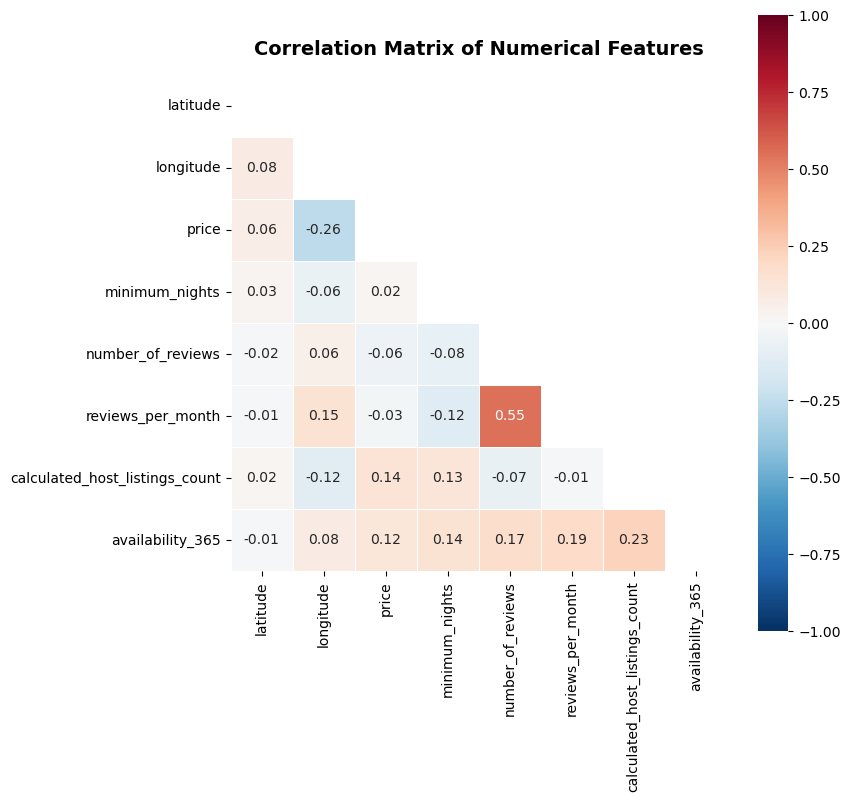

In [ ]:
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 8))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", vmax=1, vmin=-1, center=0, square=True, linewidths=.5, annot=True, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features", fontsize=14, fontweight="bold", pad=15)
plt.show()